In [4]:
!pip install wfdb -q

from google.colab import drive, userdata

drive.mount('/content/drive')
%cd /content/drive/MyDrive/project-cardia

token = userdata.get('GHToken')

!git remote set-url origin https://{token}@github.com/RafaelWhoa/project-cardia.git
!git pull

import wfdb
import os
import sys
sys.path.append('/content/drive/MyDrive/project-cardia/src')
import matplotlib.pyplot as plt
from preprocessing import build_dataset, RECORD_IDS
from dataset import build_dataloaders
from model import CNNLSTMClassifier
from train import train_model, evaluate_model
from visualize import plot_confusion_matrix, plot_training_history
from inference import load_model, predict_from_record, plot_prediction

data_version = '1.0.0'
data_folder = f'data/physionet.org/files/mitdb/{data_version}'

wfdb.dl_database('mitdb', dl_dir=data_folder)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/project-cardia
Already up to date.
Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 107
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating record list for: 121
Generating record list for: 122
Generating record list for: 123
Generating record list for: 124
Generating record list for: 200
Generating record list for: 201
Generating re

In [5]:
X, y = build_dataset(data_folder, RECORD_IDS)

print(f'\nTotal: {X.shape[0]} batimentos, janela de {X.shape[1]} amostras')
print('Distribuição de classes:')

from preprocessing import CLASS_TO_IDX
import numpy as np

for cls, idx in CLASS_TO_IDX.items():
    count = np.sum(y == idx)
    print(f'  {cls}: {count} ({100*count/len(y):.2f}%)')

os.makedirs('data/processed', exist_ok=True)

np.save('data/processed/X.npy', X)
np.save('data/processed/y.npy', y)

Registro 100: 2271 batimentos
Registro 101: 1864 batimentos
Registro 102: 2185 batimentos
Registro 103: 2083 batimentos
Registro 104: 2227 batimentos
Registro 105: 2572 batimentos
Registro 106: 2027 batimentos
Registro 107: 2136 batimentos
Registro 108: 1762 batimentos
Registro 109: 2530 batimentos
Registro 111: 2124 batimentos
Registro 112: 2537 batimentos
Registro 113: 1793 batimentos
Registro 114: 1879 batimentos
Registro 115: 1951 batimentos
Registro 116: 2411 batimentos
Registro 117: 1534 batimentos
Registro 118: 2277 batimentos
Registro 119: 1987 batimentos
Registro 121: 1861 batimentos
Registro 122: 2474 batimentos
Registro 123: 1517 batimentos
Registro 124: 1618 batimentos
Registro 200: 2600 batimentos
Registro 201: 1962 batimentos
Registro 202: 2135 batimentos
Registro 203: 2979 batimentos
Registro 205: 2655 batimentos
Registro 207: 1859 batimentos
Registro 208: 2953 batimentos
Registro 209: 3004 batimentos
Registro 210: 2648 batimentos
Registro 212: 2747 batimentos
Registro 2

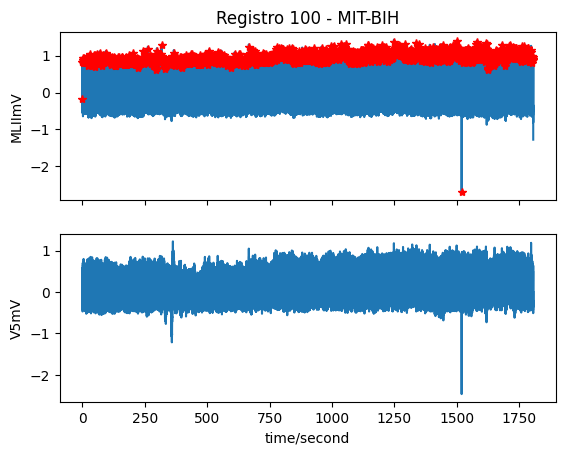

In [6]:
record = wfdb.rdrecord(f'{data_folder}/100')
annotation = wfdb.rdann(f'{data_folder}/100', 'atr')

wfdb.plot_wfdb(record=record, annotation=annotation, title='Registro 100 - MIT-BIH', time_units='seconds')

In [7]:
train_loader, val_loader, test_loader, class_weights = build_dataloaders(X, y, batch_size=128)

model = CNNLSTMClassifier(n_classes=5)

model, history = train_model(
    model, train_loader, val_loader, class_weights,
    n_epochs=30, patience=5,
    checkpoint_path='models/best_model.pt'
)

evaluate_model(model, test_loader)

Treino: 76606 | Validação: 16416 | Teste: 16416
Pesos de classe (N,S,V,F,Q): [0.2416326254606247, 7.869132041931152, 3.0255134105682373, 27.310516357421875, 2.7228007316589355]
Usando device: cuda
Época 01 | train_loss: 0.5314 | val_loss: 0.3593 | val_f1_macro: 0.6927
  -> novo melhor modelo salvo (val_f1_macro: 0.6927)
Época 02 | train_loss: 0.2950 | val_loss: 0.3843 | val_f1_macro: 0.6335
Época 03 | train_loss: 0.2299 | val_loss: 0.2591 | val_f1_macro: 0.7018
  -> novo melhor modelo salvo (val_f1_macro: 0.7018)
Época 04 | train_loss: 0.2069 | val_loss: 0.2440 | val_f1_macro: 0.7229
  -> novo melhor modelo salvo (val_f1_macro: 0.7229)
Época 05 | train_loss: 0.1675 | val_loss: 0.2360 | val_f1_macro: 0.7744
  -> novo melhor modelo salvo (val_f1_macro: 0.7744)
Época 06 | train_loss: 0.1793 | val_loss: 0.2541 | val_f1_macro: 0.7065
Época 07 | train_loss: 0.1568 | val_loss: 0.2312 | val_f1_macro: 0.7576
Época 08 | train_loss: 0.1329 | val_loss: 0.2036 | val_f1_macro: 0.7533
Época 09 | trai

([np.int64(4),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(4),
  np.int64(1),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(2),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(4),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(4),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(4),
  np.int64(0),
  np.int64(2),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(2),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(1),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64


=== Relatório de classificação (conjunto de teste) ===
              precision    recall  f1-score   support

           N      0.997     0.989     0.993     13588
           S      0.840     0.942     0.888       417
           V      0.946     0.981     0.963      1085
           F      0.769     0.826     0.797       121
           Q      0.993     0.997     0.995      1205

    accuracy                          0.987     16416
   macro avg      0.909     0.947     0.927     16416
weighted avg      0.987     0.987     0.987     16416

=== Matriz de confusão ===
[[13439    68    49    24     8]
 [   20   393     3     0     1]
 [    9     6  1064     6     0]
 [   11     1     9   100     0]
 [    4     0     0     0  1201]]


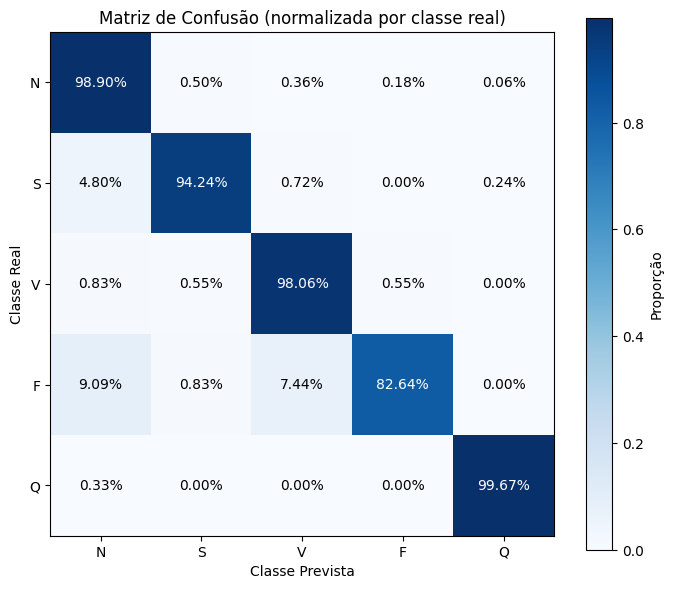

In [8]:
labels, preds = evaluate_model(model, test_loader)
plot_confusion_matrix(labels, preds)

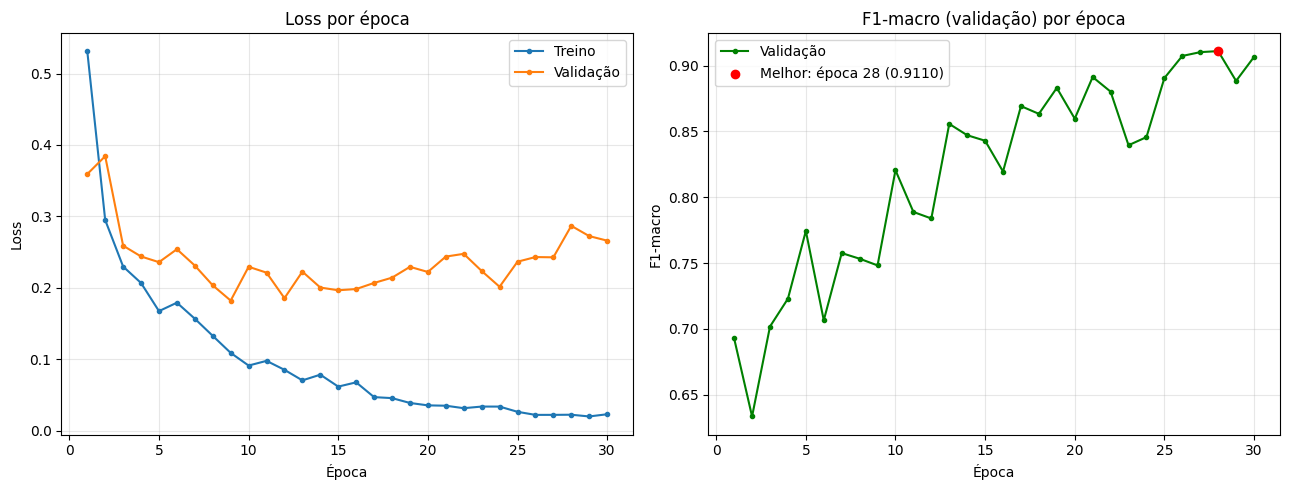

In [9]:
plot_training_history(history)

Previsão: N | Anotação real (símbolo original): N
Probabilidades: {'N': 0.9999884366989136, 'S': 7.887059837230481e-06, 'V': 4.54929732995879e-07, 'F': 2.9418631584121613e-06, 'Q': 2.546469204389723e-07}


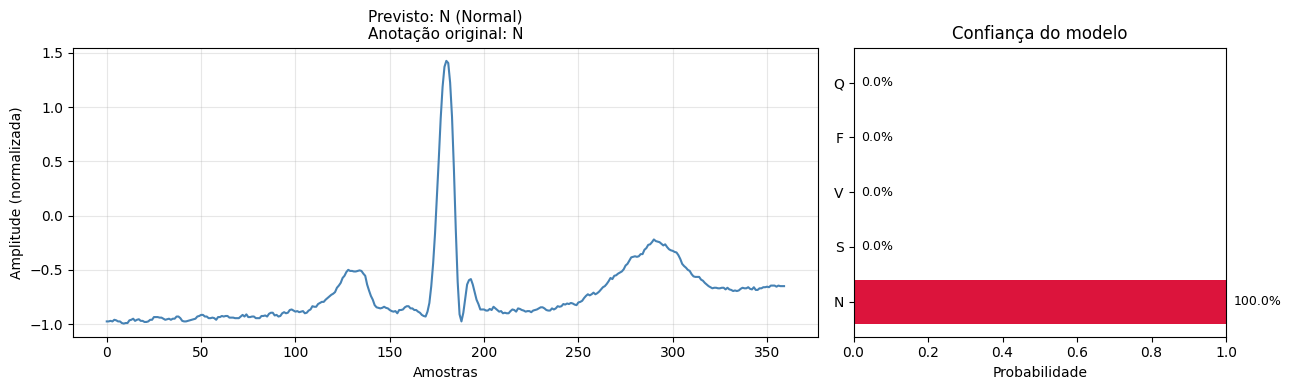

In [87]:
model, device = load_model('/content/drive/MyDrive/project-cardia/models/best_model.pt')

window, pred_class, probs, true_symbol = predict_from_record(
    model, device, f'{data_folder}/119', beat_index=30
)

print(f'Previsão: {pred_class} | Anotação real (símbolo original): {true_symbol}')
print(f'Probabilidades: {probs}')

plot_prediction(window, pred_class, probs, true_symbol)